# μBoone open data set anomaly detection

Note: The data needs to be downloaded seperately on your own. Open source data, python scripts, and jupyter notebooks derived from: https://github.com/uboone/OpenSamples/tree/main. Files downloaded should be put into the data folder. Furthermore this notebook will use only one file of the open wire data. Otherwise this project is way too heavy for what's intended to be a tutorial or supplement to the SCARAB project.

Before using this notebook follow the instructions listed in the OpenSamples repository, notably setting up the `ubopendata` conda environment with all the necessary libraries and packages. Furthermore, to best understand the autoencoder features for the microBooNe open data set, it's recommended to use the notebooks developed in the OpenSamples repository. 

The overall methodology of this will follow the unsupervised learning process developed by https://arxiv.org/pdf/2310.06047 and https://arxiv.org/abs/2509.21817v3. However, we will omit the student-teacher knowledge distillation methodology as we are constraining our training to a few files and with limited hardware, essentially only building the "teacher" autoencoder.

### Import libraries and useful data

Before this ensure you have set up the `ubopendata` conda environment which can be done by following the instructions from the OpenSamples repo. Put the wire data (one file or multiple) iun the data folder and ideally in its own sub folder (example provided below).

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from pathlib import Path

# Directly from uboone repo. Credits to Giuseppe Cerati for his code.
from microboone_utils import *
from pynuml.io import File


In [7]:
# walk up to the repo root, then into the data folder
repo_root = Path.cwd().parents[1]        # ../../ from tutorial/MBOONE
f = File(repo_root / "data" / "ubopendata" / "bnb_WithWire_00.h5")

# Print keys to see the structure of any useful data
print(f.keys())

<KeysViewHDF5 ['edep_table', 'event_table', 'hit_table', 'opflash_table', 'opflashsumpe_table', 'ophit_table', 'pandoraHit_table', 'pandoraPfp_table', 'pandoraPrimary_table', 'particle_table', 'wire_table']>


### Extracting useful data (wire)

Following the methodology from the RAD4HEP repository: https://github.com/NevisRAD/RAD4LArTPC/tree/main, we downsample to shrink the large data from all planes to only plane2. Any future modifications to the data will be made here in the notebook but otherwise process the data in `mod_data.py`. 

Make sure to conda activate `ubopendata` first and/or run `conda run --no-capture-output -n ubopendata python tutorial/MBOONE/mod_data.py` in the terminal. The reasons for these are due to errors presented when pressing the run button. This will process the bnb_WithWire file into a processed plane2 only file. However make sure you switch the name of the file if needed which will be found on line 71 in `mod_data.py`. Now there will be a new wire image data set sourced from below. 

In [8]:
from mod_data_loader import WireImages

data = WireImages("../../data/ubopendata/processed_npy/bnb_WithWire_00_plane2_images.h5")
print(len(data), "events") # Sanity check


1085 events


### Getting key images from processed file 

Using the `mod_data_loader.py` script will allow us to use all the key information from the plane 2 wire data. Many images follow directly from `WireImage.ipynb` directly from: https://github.com/uboone/OpenSamples/tree/main, thus the goal for this is to sanity check that processing our file had no change to the data and is only for downscaling purposes. This will require using both unprocessed and processed files.

In [9]:
#Unprocessed original data (only a few events!). Reading 50 events of WithWire
# data at once is ~10 GB and triggers a MemoryError; we only need a couple of
# events to sanity-check the processed file against the raw file.
tables = ['event_table','wire_table','hit_table','edep_table']
for t in tables: f.add_group(t)
f.read_data(0, 5)
evts = f.build_evt()

### Plane 2 wire image with cuts (from the processed file)

This reproduces the **Plane 2** panel of `WireImage.ipynb`, but sourced from our compressed, plane-2-only processed file through `WireImages`. The loader applies the cutoff / saturation cuts on the fly (`cut=True`) and only reads the one event's chunk from disk. The time axis is downsampled by 10, so it spans 640 ticks instead of 6400.

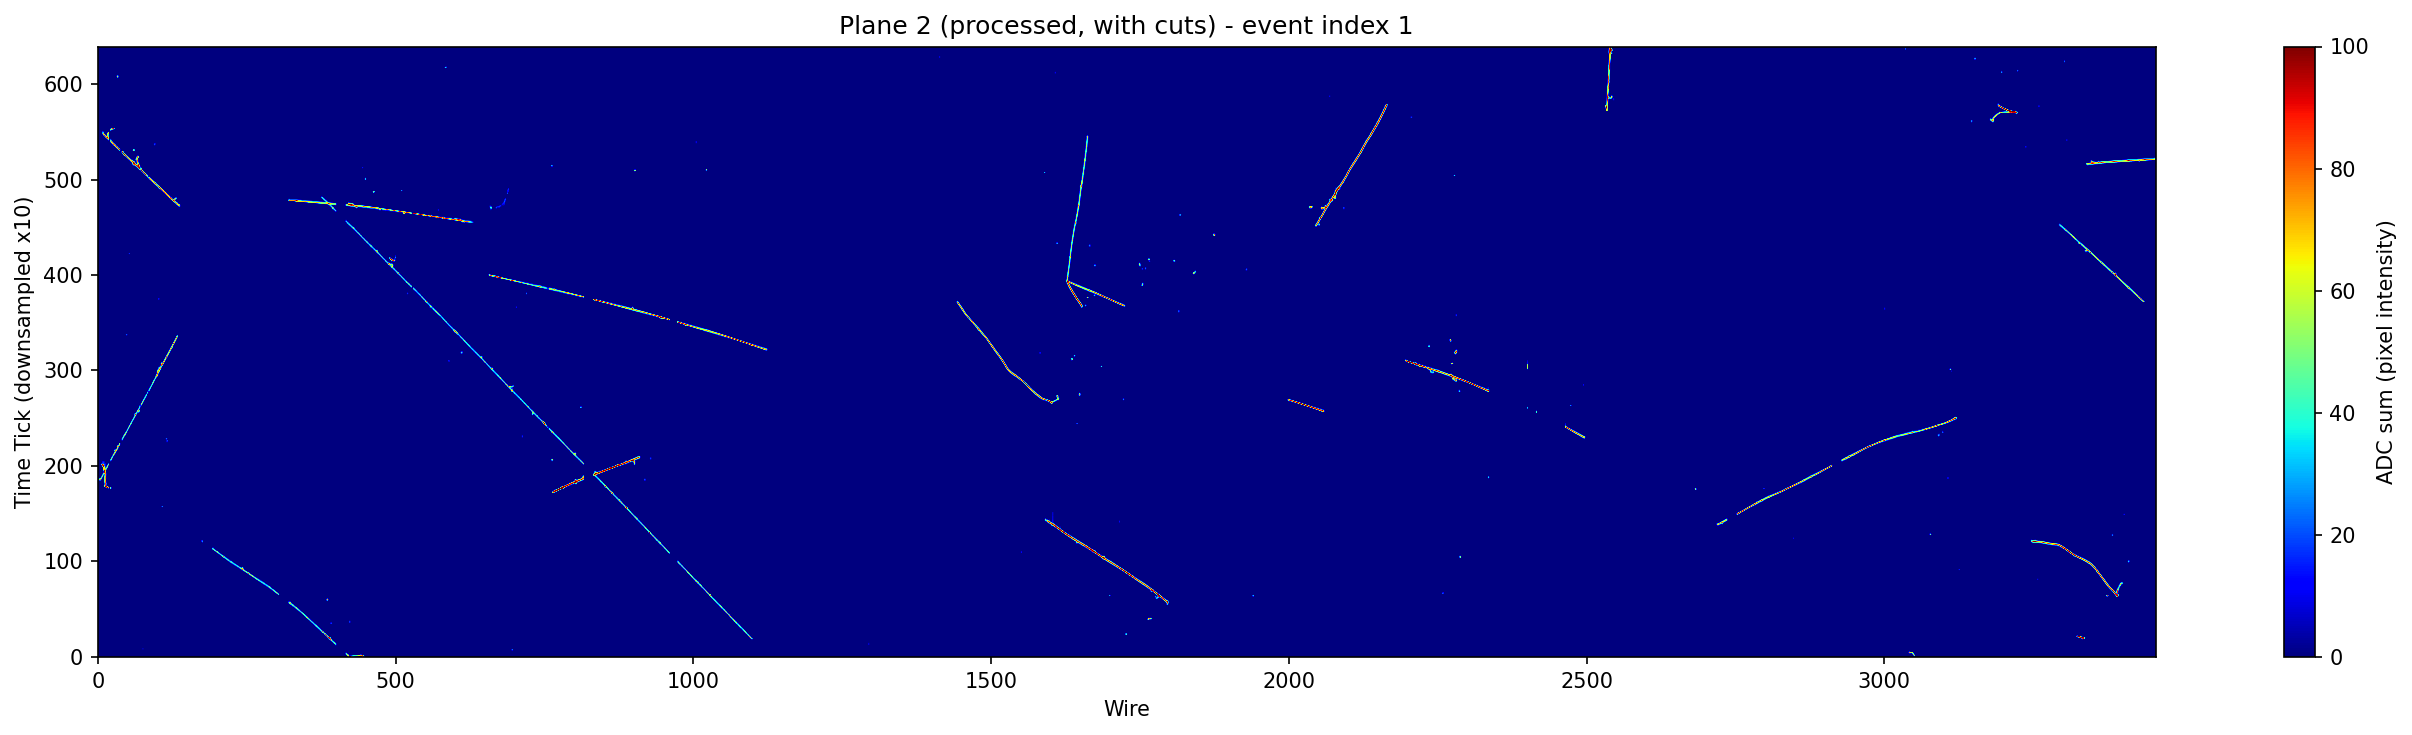

In [10]:
evt_index = 1   # which event to display (0 .. len(data)-1)

# Processed plane-2 image, cuts applied on the fly by the loader.
img_cut = data.full_image(evt_index, cut=True)   # shape (nwires=3456, time=640)
zmax = data.saturation                            # saturation value stored in the file (100)

plt.figure(figsize=(18, 5), dpi=150)
# transpose so Wire is on x and Time Tick on y, matching WireImage.ipynb
plt.imshow(img_cut.T, vmin=0, vmax=zmax, origin="lower", cmap="jet", aspect="auto")
plt.title("Plane 2 (processed, with cuts) - event index %d" % evt_index)
plt.xlabel("Wire")
plt.ylabel("Time Tick (downsampled x10)")
plt.colorbar(label="ADC sum (pixel intensity)")
plt.tight_layout()
plt.show()

### Sanity check: processed vs. unprocessed

To confirm the processing only downscaled the data (and didn't otherwise alter it), we recompute the same event's Plane 2 image **straight from the unprocessed file** (`evts`, loaded above) using the identical downsample factor (10) and cuts (10 / 100), then compare pixel-for-pixel.

The two agree to floating-point rounding (`max |diff|` ~ 1e-5, from the pandas `float64` path vs. the stored `float32`) — i.e. the processing changed nothing beyond the downsampling and cuts. With `evt_index = 1` this is event `(7004, 331, 16552)`, the same event shown in `WireImage.ipynb`.

event (run, subrun, event): [7004, 331, 16552]
shapes -> processed: (3456, 640)  raw recompute: (3456, 640)
max |processed - raw| = 1.52587890625e-05


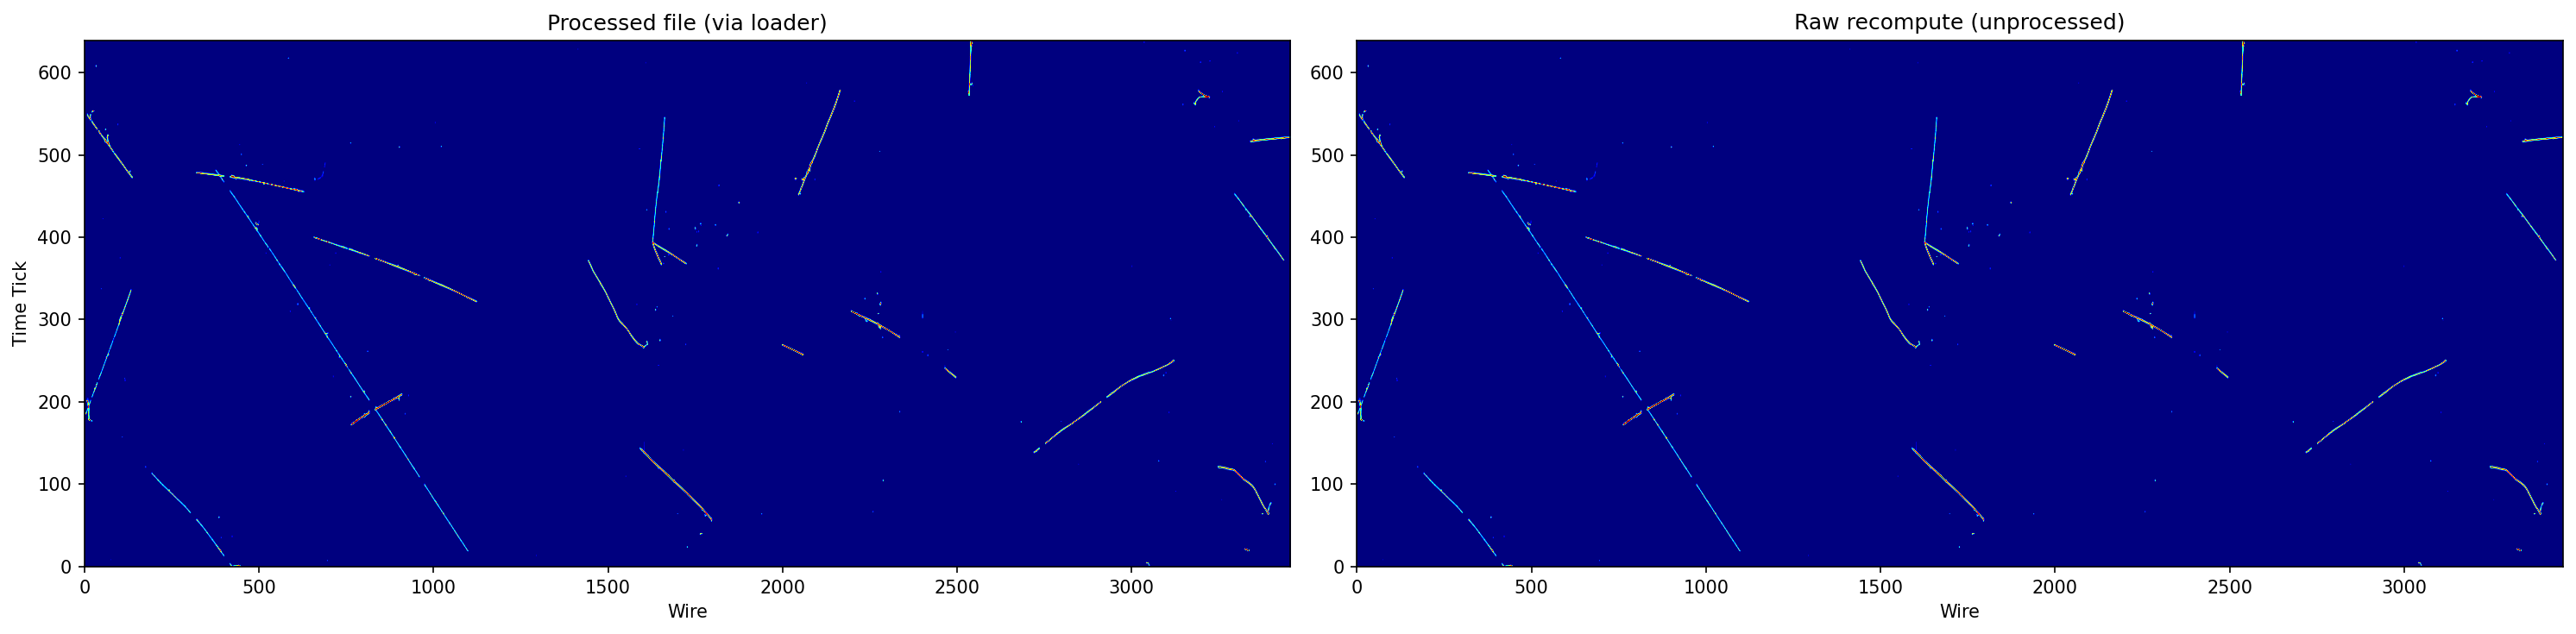

In [11]:
from skimage.measure import block_reduce

# Recompute plane 2 for the SAME event straight from the raw wire_table.
# (evt_index must be < the number of events read in the "Unprocessed original data" cell.)
evt = evts[evt_index]
evt_id = [evt["event_table"]["run"].iloc[0],
          evt["event_table"]["subrun"].iloc[0],
          evt["event_table"]["event"].iloc[0]]

raw_p2 = evt["wire_table"].query("local_plane==2")[
    ["adc_%i" % i for i in range(ntimeticks())]].to_numpy()
raw_ds = block_reduce(raw_p2, block_size=(1, 10), func=np.sum)   # downsample x10
raw_cut = raw_ds.copy()
raw_cut[raw_cut < data.cutoff] = 0
raw_cut[raw_cut > data.saturation] = data.saturation

print("event (run, subrun, event):", evt_id)
print("shapes -> processed:", img_cut.shape, " raw recompute:", raw_cut.shape)
print("max |processed - raw| =", float(np.max(np.abs(img_cut - raw_cut))))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(20, 5), dpi=150)
axL.imshow(img_cut.T, vmin=0, vmax=zmax, origin="lower", cmap="jet", aspect="auto")
axL.set_title("Processed file (via loader)"); axL.set_xlabel("Wire"); axL.set_ylabel("Time Tick")
axR.imshow(raw_cut.T, vmin=0, vmax=zmax, origin="lower", cmap="jet", aspect="auto")
axR.set_title("Raw recompute (unprocessed)"); axR.set_xlabel("Wire")
plt.tight_layout()
plt.show()